# 01 – Exploration

Objectif : bien connaître les données avant de construire un modèle. On regarde :

1. la **cible** : combien de clients font défaut ?
2. les **valeurs manquantes** : quelles colonnes ont des trous, et est-ce que ces trous disent quelque chose ?
3. la **distribution** de chaque variable : quelles valeurs sont fréquentes, lesquelles sont extrêmes ?
4. le **lien avec le défaut** : est-ce que le taux de défaut change selon la valeur de la variable ?
5. les **valeurs bizarres** : erreurs, codes spéciaux, valeurs impossibles.

Aucune donnée n'est modifiée ici. Les corrections seront faites dans le notebook `02_preparation`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = '../data/cs-training.csv'
TARGET = 'SeriousDlqin2yrs'

# Style des graphiques
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#52514e'
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GREY, 'axes.labelcolor': GREY,
    'xtick.color': GREY, 'ytick.color': GREY,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6,
    'axes.axisbelow': True,
})
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
pd.set_option('display.max_columns', 20)

## 0. Chargement et description des colonnes

La première colonne du fichier est un simple numéro de ligne : on l'utilise comme index.

In [2]:
df = pd.read_csv(DATA, index_col=0)
print(df.shape)
df.head()

(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766,45,2,0.803,"9,120.000",13,0,6,0,2.000
2,0,0.957,40,0,0.122,"2,600.000",4,0,0,0,1.000
3,0,0.658,38,1,0.085,"3,042.000",2,1,0,0,0.000
4,0,0.234,30,0,0.036,"3,300.000",5,0,0,0,0.000
5,0,0.907,49,1,0.025,"63,588.000",7,0,1,0,0.000


Ce que veut dire chaque colonne :

| Colonne | Signification |
|---|---|
| `SeriousDlqin2yrs` | **Cible.** 1 si le client a eu un retard de 90 jours ou plus dans les 2 ans, 0 sinon |
| `RevolvingUtilizationOfUnsecuredLines` | Part utilisée des crédits renouvelables (cartes de crédit, découverts) : solde dû ÷ plafond autorisé. Normalement entre 0 et 1 |
| `age` | Âge de l'emprunteur, en années |
| `NumberOfTime30-59DaysPastDueNotWorse` | Nombre de fois où le client a eu un retard de 30 à 59 jours (sur les 2 dernières années) |
| `DebtRatio` | Taux d'endettement : dépenses mensuelles (remboursements, pension, loyer) ÷ revenu mensuel |
| `MonthlyIncome` | Revenu mensuel |
| `NumberOfOpenCreditLinesAndLoans` | Nombre de crédits en cours (prêts et cartes) |
| `NumberOfTimes90DaysLate` | Nombre de fois où le client a eu un retard de 90 jours ou plus |
| `NumberRealEstateLoansOrLines` | Nombre de prêts immobiliers |
| `NumberOfTime60-89DaysPastDueNotWorse` | Nombre de fois où le client a eu un retard de 60 à 89 jours |
| `NumberOfDependents` | Nombre de personnes à charge (enfants, conjoint…) |

In [3]:
# Noms courts pour les graphiques
SHORT = {
    'RevolvingUtilizationOfUnsecuredLines': 'Utilisation crédit renouvelable',
    'age': 'Âge',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Retards 30-59 j',
    'DebtRatio': "Taux d'endettement",
    'MonthlyIncome': 'Revenu mensuel',
    'NumberOfOpenCreditLinesAndLoans': 'Crédits en cours',
    'NumberOfTimes90DaysLate': 'Retards 90 j et +',
    'NumberRealEstateLoansOrLines': 'Prêts immobiliers',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Retards 60-89 j',
    'NumberOfDependents': 'Personnes à charge',
}
FEATURES = list(SHORT)

# Signification courte, affichée sous le nom de la colonne dans les graphiques
DESC = {
    'RevolvingUtilizationOfUnsecuredLines': 'Part utilisée des cartes / découverts (solde ÷ plafond)',
    'age': "Âge de l'emprunteur (années)",
    'NumberOfTime30-59DaysPastDueNotWorse': 'Nb de retards de 30 à 59 jours',
    'DebtRatio': "Taux d'endettement (dépenses mensuelles ÷ revenu)",
    'MonthlyIncome': 'Revenu mensuel ($)',
    'NumberOfOpenCreditLinesAndLoans': 'Nb de crédits en cours (prêts + cartes)',
    'NumberOfTimes90DaysLate': 'Nb de retards de 90 jours ou plus',
    'NumberRealEstateLoansOrLines': 'Nb de prêts immobiliers',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Nb de retards de 60 à 89 jours',
    'NumberOfDependents': 'Nb de personnes à charge',
}

def plot_title(col, extra=''):
    # Titre de graphique : nom de la colonne + sa signification
    return f'{col}\n{DESC[col]}{extra}'

df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## 1. La cible : combien de clients font défaut ?

Taux de défaut : 6.68%  (10,026 défauts sur 150,000 clients)


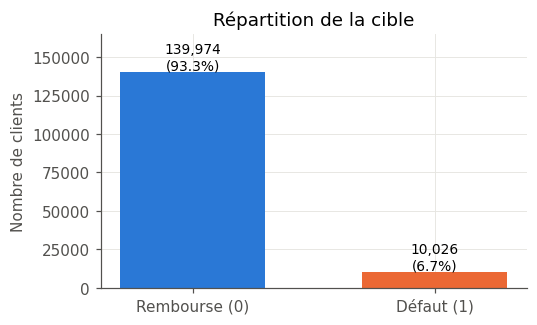

In [4]:
counts = df[TARGET].value_counts().sort_index()
rate = df[TARGET].mean()
print(f"Taux de défaut : {rate:.2%}  ({counts[1]:,} défauts sur {len(df):,} clients)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Rembourse (0)', 'Défaut (1)'], counts.values, color=[BLUE, ORANGE], width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}\n({v/len(df):.1%})', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Nombre de clients')
ax.set_ylim(0, counts.max() * 1.18)
ax.set_title('Répartition de la cible')
plt.show()

**À retenir.** Environ **6,7 %** des clients font défaut. Les classes sont donc très **déséquilibrées** : il y a environ 14 bons clients pour 1 mauvais.

Conséquence : un modèle qui prédit « rembourse » pour tout le monde aurait 93 % de bonnes réponses tout en étant inutile. C'est pour ça qu'on utilisera l'AUC, le Gini et le KS (voir le README). Il faudra aussi garder la même proportion de défauts dans les jeux d'entraînement et de test (découpage *stratifié*).

## 2. Valeurs manquantes

In [5]:
na = pd.DataFrame({
    'nb_manquants': df.isna().sum(),
    'pct_manquants': df.isna().mean() * 100,
}).query('nb_manquants > 0')
na

,nb_manquants,pct_manquants
MonthlyIncome,29731,19.821
NumberOfDependents,3924,2.616


Seules deux colonnes ont des trous : le **revenu mensuel** (environ 20 % des clients) et le **nombre de personnes à charge** (environ 2,6 %).

Question importante : est-ce que les clients sans revenu renseigné sont différents des autres ? Si oui, le fait que la valeur manque est lui-même une information.

In [6]:
for col in ['MonthlyIncome', 'NumberOfDependents']:
    t = df.groupby(df[col].isna())[TARGET].agg(['size', 'mean'])
    t.index = ['renseigné', 'manquant']
    t.columns = ['nb_clients', 'taux_defaut']
    print(f'--- {SHORT[col]} ---')
    print(t, '\n')

both = df['MonthlyIncome'].isna() & df['NumberOfDependents'].isna()
print(f"Clients sans personnes à charge renseignées : {df['NumberOfDependents'].isna().sum():,}")
print(f"... dont revenu aussi manquant : {both.sum():,}")

--- Revenu mensuel ---
           nb_clients  taux_defaut
renseigné      120269        0.069
manquant        29731        0.056 

--- Personnes à charge ---
           nb_clients  taux_defaut
renseigné      146076        0.067
manquant         3924        0.046 

Clients sans personnes à charge renseignées : 3,924
... dont revenu aussi manquant : 3,924


**À retenir.**
- Les clients **sans revenu renseigné font moins défaut** (environ 5,6 %) que les autres (environ 6,9 %). Le manque n'est donc pas dû au hasard : il faudra garder cette information (par exemple une colonne « revenu manquant : oui/non ») au lieu de simplement remplacer par la moyenne.
- Presque tous les clients sans « personnes à charge » n'ont **pas de revenu non plus** : les deux trous viennent probablement de la même cause (dossier incomplet).

## 3. Distributions des variables

On commence par un résumé chiffré. On regarde surtout l'écart entre le 99ᵉ percentile (la valeur sous laquelle se trouvent 99 % des clients) et le maximum : un énorme écart signale des valeurs extrêmes.

In [7]:
df[FEATURES].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

,count,mean,std,min,1%,25%,50%,75%,99%,max
RevolvingUtilizationOfUnsecuredLines,"150,000.000",6.048,249.755,0.000,0.000,0.030,0.154,0.559,1.093,"50,708.000"
age,"150,000.000",52.295,14.772,0.000,24.000,41.000,52.000,63.000,87.000,109.000
NumberOfTime30-59DaysPastDueNotWorse,"150,000.000",0.421,4.193,0.000,0.000,0.000,0.000,0.000,4.000,98.000
DebtRatio,"150,000.000",353.005,"2,037.819",0.000,0.000,0.175,0.367,0.868,"4,979.040","329,664.000"
MonthlyIncome,"120,269.000","6,670.221","14,384.674",0.000,0.000,"3,400.000","5,400.000","8,249.000","25,000.000","3,008,750.000"
NumberOfOpenCreditLinesAndLoans,"150,000.000",8.453,5.146,0.000,0.000,5.000,8.000,11.000,24.000,58.000
NumberOfTimes90DaysLate,"150,000.000",0.266,4.169,0.000,0.000,0.000,0.000,0.000,3.000,98.000
NumberRealEstateLoansOrLines,"150,000.000",1.018,1.130,0.000,0.000,0.000,1.000,2.000,4.000,54.000
NumberOfTime60-89DaysPastDueNotWorse,"150,000.000",0.240,4.155,0.000,0.000,0.000,0.000,0.000,2.000,98.000
NumberOfDependents,"146,076.000",0.757,1.115,0.000,0.000,0.000,0.000,1.000,4.000,20.000


Plusieurs maximums sont déjà suspects : une utilisation de crédit de **50 708** (alors qu'elle devrait être entre 0 et 1), un taux d'endettement de **329 664**, un âge minimum de **0**, et **98** retards sur 2 ans. On y revient en détail dans la partie 5.

Pour que les histogrammes restent lisibles, on coupe l'axe au 99ᵉ percentile (les 1 % les plus extrêmes ne sont pas dessinés). Pour le taux d'endettement, même cela ne suffit pas : on zoome sur les valeurs entre 0 et 2.

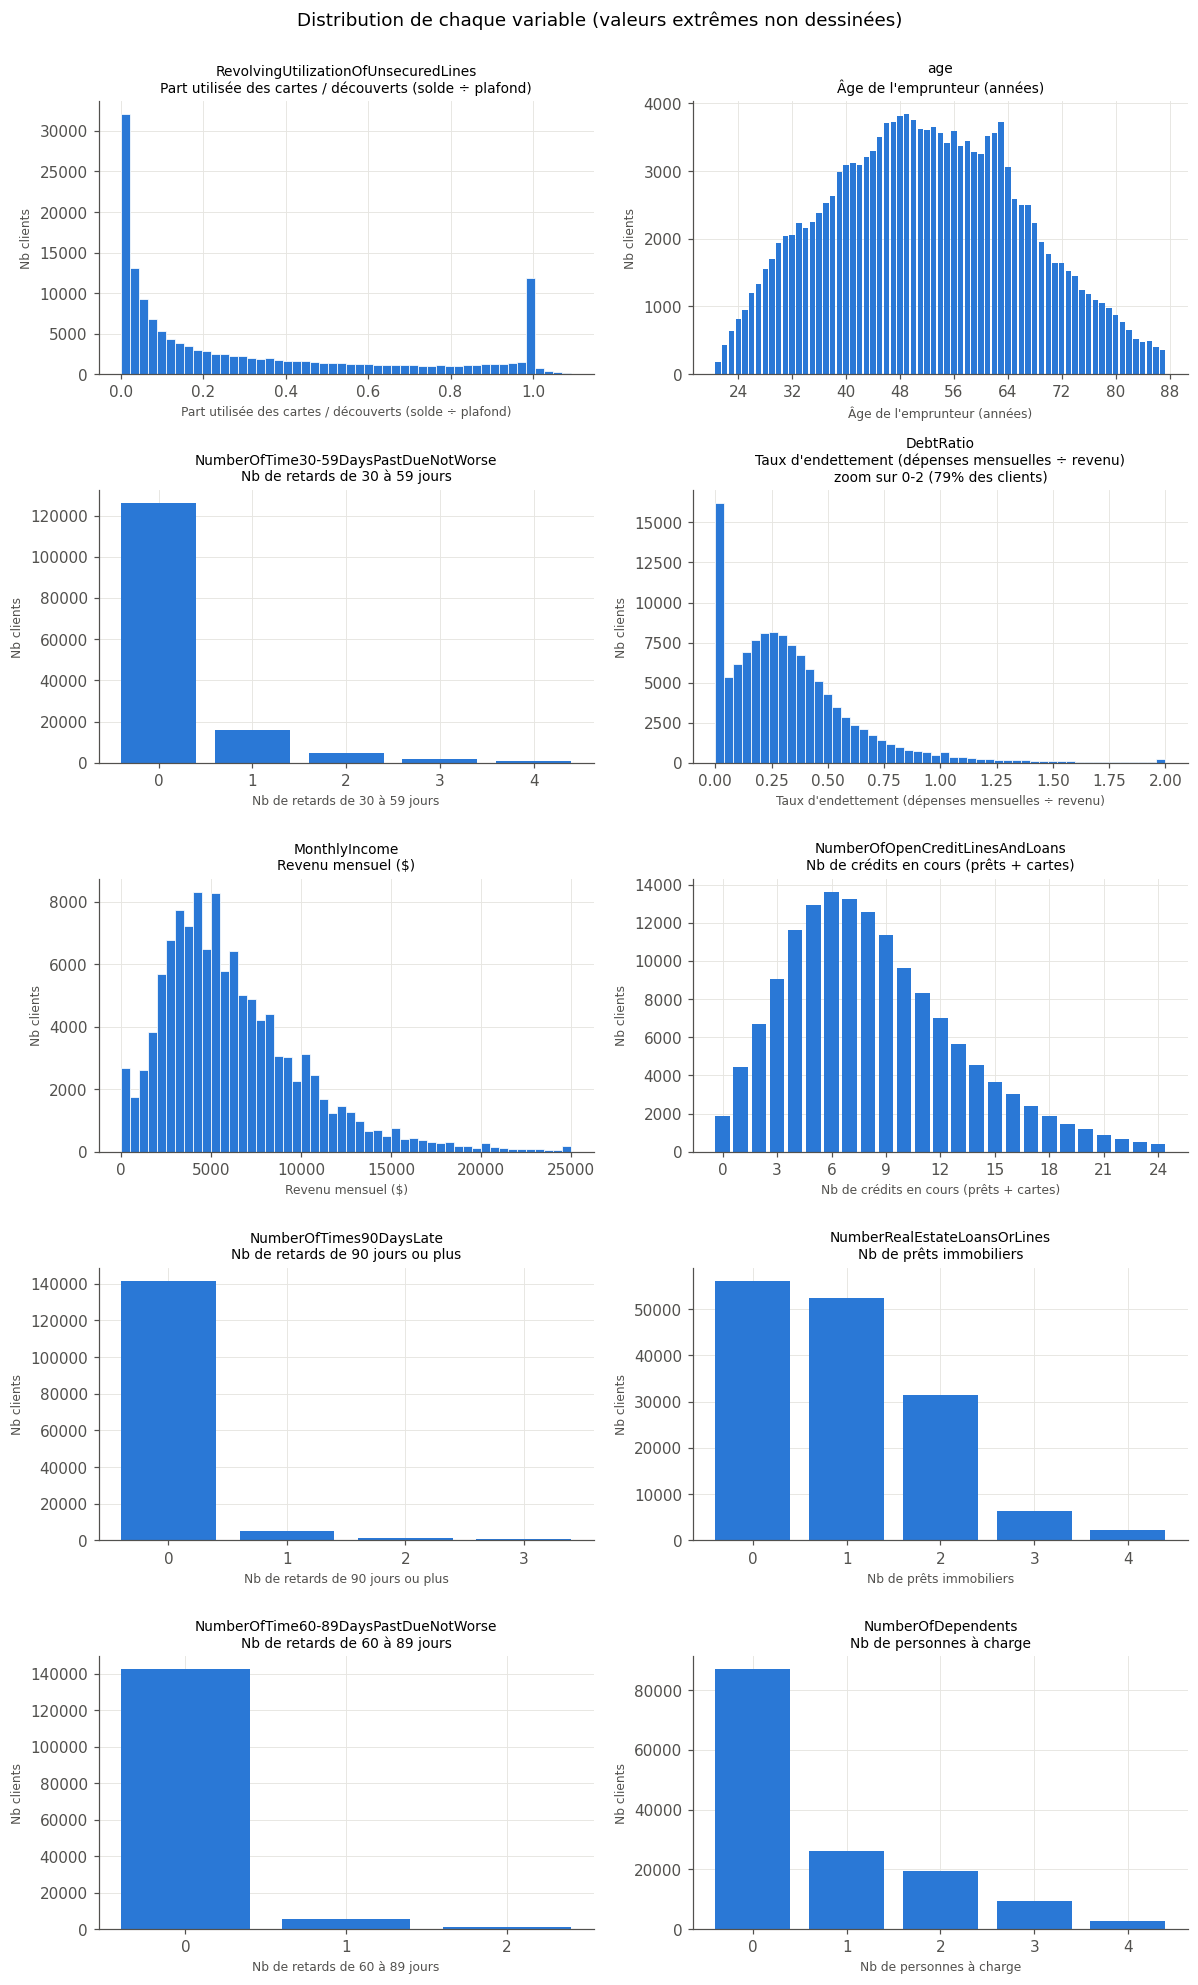

In [8]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(5, 2, figsize=(11, 18))
for ax, col in zip(axes.ravel(), FEATURES):
    s = df[col].dropna()
    extra = ''
    if col == 'DebtRatio':
        # Même coupé au 99e percentile, la traîne écrase tout : on zoome sur 0-2
        share = (s <= 2).mean()
        s = s[s <= 2]
        extra = f'\nzoom sur 0-2 ({share:.0%} des clients)'
    else:
        s = s[(s >= s.quantile(0.001)) & (s <= s.quantile(0.99))]
    if pd.api.types.is_integer_dtype(df[col]) or col == 'NumberOfDependents':
        vc = s.value_counts().sort_index()
        ax.bar(vc.index, vc.values, color=BLUE, width=0.8)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        ax.hist(s, bins=50, color=BLUE, edgecolor='white', linewidth=0.5)
    ax.set_title(plot_title(col, extra), fontsize=9)
    ax.set_xlabel(DESC[col], fontsize=8)
    ax.set_ylabel('Nb clients', fontsize=8)
fig.suptitle('Distribution de chaque variable (valeurs extrêmes non dessinées)', y=1.0)
fig.tight_layout()
plt.show()

**À retenir.**
- **L'âge** a une forme proche d'une cloche, centrée vers 50 ans. C'est la variable la plus « propre ».
- **Les trois variables de retards** valent 0 pour la grande majorité des clients : la plupart n'ont jamais été en retard.
- **Le revenu, l'utilisation du crédit et le taux d'endettement** sont très **asymétriques** : beaucoup de petites valeurs et une longue traîne de grandes valeurs. Il faudra les découper en tranches (pour la régression logistique) ou les transformer.
- **L'utilisation du crédit** a un pic net à 0 (aucune carte utilisée) et un autre pic proche de 1 (plafond atteint).

## 4. Lien entre chaque variable et le taux de défaut

Pour chaque variable, on regroupe les clients en tranches et on calcule le **taux de défaut** dans chaque tranche.
- Variables continues (âge, revenu…) : 10 tranches de même taille (déciles), chacune contient environ 10 % des clients.
- Variables de comptage (nombre de retards, de crédits…) : on garde les valeurs telles quelles, en regroupant les grandes valeurs dans une dernière tranche « N et + ».

La ligne pointillée est le taux de défaut moyen (6,7 %). Les clients avec une valeur manquante forment une tranche à part (en orange).

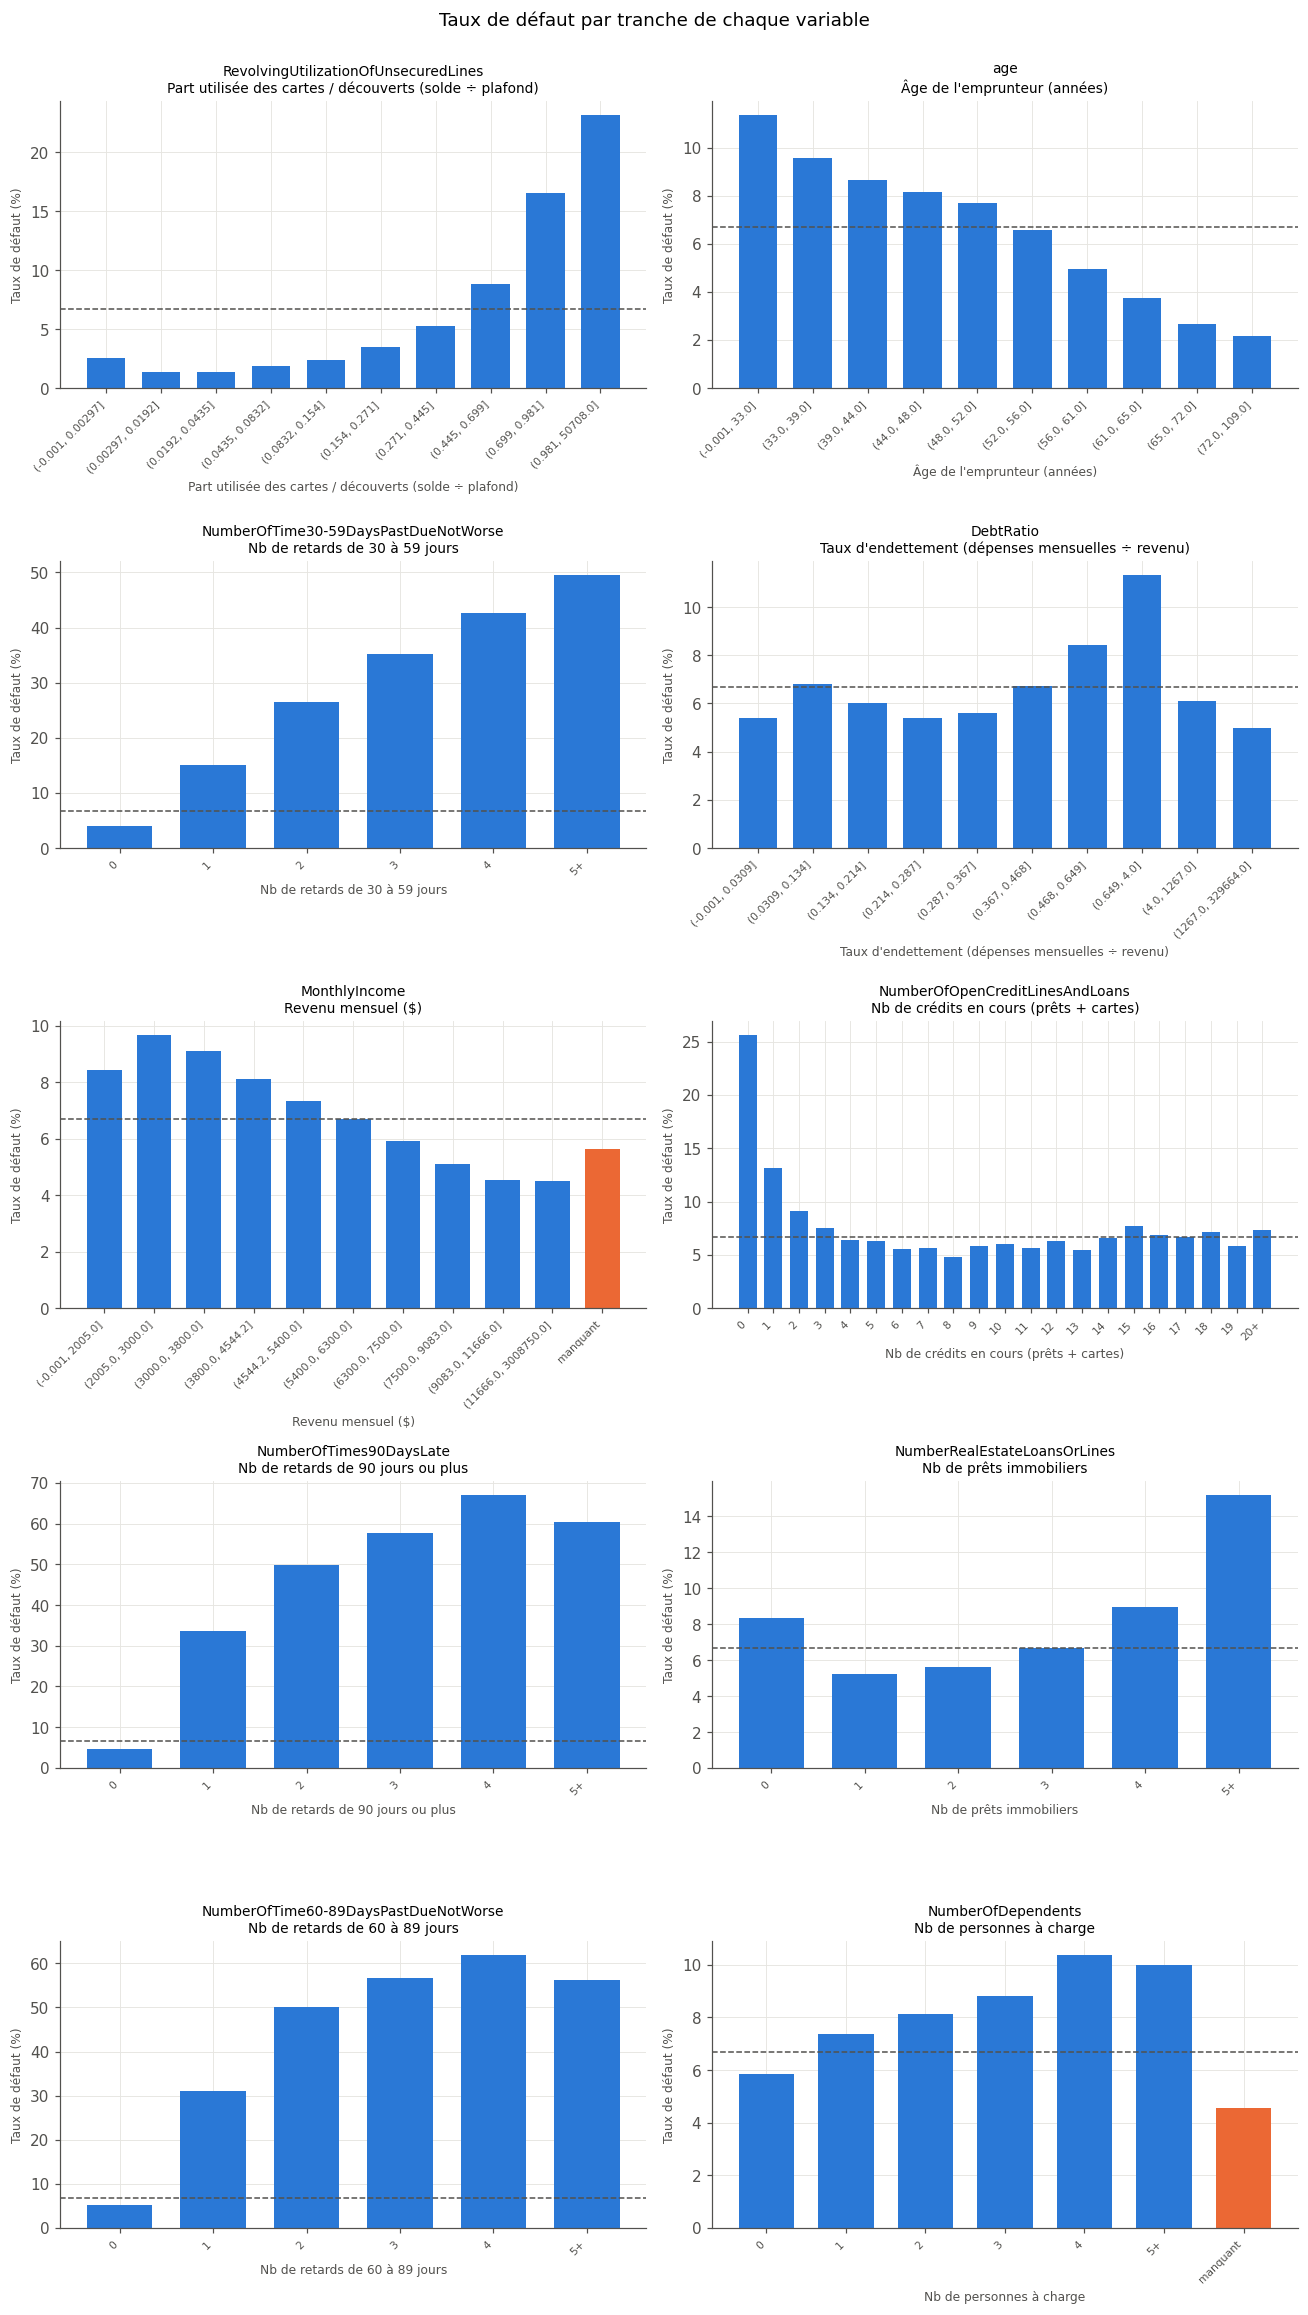

In [19]:
CAPS = {  # au-delà de cette valeur, on regroupe dans « N et + »
    'NumberOfTime30-59DaysPastDueNotWorse': 5,
    'NumberOfTimes90DaysLate': 5,
    'NumberOfTime60-89DaysPastDueNotWorse': 5,
    'NumberRealEstateLoansOrLines': 5,
    'NumberOfDependents': 5,
    'NumberOfOpenCreditLinesAndLoans': 20,
}

def default_by_bin(col):
    s = df[col]
    if col in CAPS:
        cap = CAPS[col]
        bins = s.clip(upper=cap).astype('Int64').astype(str).replace(str(cap), f'{cap}+')
        order = [str(i) for i in range(cap)] + [f'{cap}+']
    else:
        bins = pd.qcut(s, 10, duplicates='drop')
        order = list(bins.cat.categories)
        bins = bins.astype(str)
        order = [str(o) for o in order]
    bins = bins.where(s.notna(), 'manquant')
    if s.isna().any():
        order.append('manquant')
    t = df.groupby(bins)[TARGET].agg(['size', 'mean']).reindex(order).dropna()
    return t

fig, axes = plt.subplots(5, 2, figsize=(12, 21))
for ax, col in zip(axes.ravel(), FEATURES):
    t = default_by_bin(col)
    x = np.arange(len(t))
    colors = [ORANGE if i == 'manquant' else BLUE for i in t.index]
    ax.bar(x, t['mean'] * 100, color=colors, width=0.7)
    ax.axhline(rate * 100, color=GREY, ls='--', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(t.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(plot_title(col), fontsize=9)
    ax.set_xlabel( DESC[col], fontsize=8)
    ax.set_ylabel('Taux de défaut (%)', fontsize=8)
fig.suptitle('Taux de défaut par tranche de chaque variable', y=1.0)
fig.tight_layout()
plt.show()

**À retenir.**
- **Les retards passés sont les signaux les plus forts.** Un client sans aucun retard de 90 jours fait défaut environ 4,6 % du temps. Avec un seul retard de ce type, on passe à 34 %, et à 50 % avec deux. Même logique pour les retards de 30-59 jours (4 % sans retard, 15 % avec un retard) et de 60-89 jours.
- **L'utilisation du crédit renouvelable** est aussi très parlante : environ 1,5 à 2,5 % de défauts quand le client utilise peu ses cartes, contre plus de 20 % quand il approche ou dépasse son plafond.
- **L'âge** : plus le client est jeune, plus il fait défaut. Le risque baisse régulièrement, d'environ 11 % avant 33 ans à environ 2 % après 72 ans.
- **Le revenu** : le risque baisse quand le revenu augmente (environ 9-10 % pour les bas revenus, 4,5 % pour les plus hauts), mais moins fortement. La tranche « manquant » est sous la moyenne (comme vu en partie 2).
- **Le taux d'endettement** monte avec l'endettement jusqu'à environ 11 % de défauts (tranche 0,65 à 4), puis **retombe** sous la moyenne pour les valeurs énormes (au-delà de 4). Un client 1 000 fois plus endetté qu'un autre devrait être plus risqué, pas moins : c'est suspect, on l'explique dans la partie 5.
- **Les crédits en cours** : les clients avec **0 crédit** font défaut environ 26 % du temps, bien plus que les autres (6 à 9 %). On verra en 5.1 qu'une partie de ces clients sont les cas bizarres « 96/98 ».
- **Les prêts immobiliers** ont une forme en U : un ou deux prêts, c'est le profil le moins risqué (environ 5,5 %). Aucun prêt (8 %) ou beaucoup de prêts (15 % pour 5 et +), c'est plus risqué.
- **Les personnes à charge** : le risque augmente un peu avec leur nombre (6 % sans personne à charge, 10 % avec 4 et +).

Plusieurs relations ne sont **pas linéaires** (forme en U, hausse puis baisse, effet de seuil). C'est une raison de découper les variables en tranches pour la régression logistique.

## 5. Chasse aux valeurs bizarres

On passe en revue chaque anomalie : ce qu'on observe, pourquoi c'est bizarre, et ce qu'on prévoit d'en faire à l'étape de préparation.

### 5.1 Les codes 96 et 98 dans les colonnes de retards

Avoir 98 retards de 30 jours en 2 ans est impossible : 2 ans ne contiennent qu'environ 24 mois. Regardons les plus grandes valeurs de ces colonnes.

In [10]:
LATE = ['NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfTimes90DaysLate']
for col in LATE:
    print(SHORT[col], '->', df[col].value_counts().sort_index().tail(5).to_dict())

Retards 30-59 j -> {11: 1, 12: 2, 13: 1, 96: 5, 98: 264}
Retards 60-89 j -> {8: 2, 9: 1, 11: 1, 96: 5, 98: 264}
Retards 90 j et + -> {14: 2, 15: 2, 17: 1, 96: 5, 98: 264}


In [11]:
weird = df[LATE].isin([96, 98]).any(axis=1)
print(f"Clients concernés : {weird.sum()}")
print(f"Les 3 colonnes valent 96/98 en même temps : {df.loc[weird, LATE].isin([96, 98]).all(axis=1).all()}")
print(f"Taux de défaut de ces clients : {df.loc[weird, TARGET].mean():.1%}  (moyenne : {rate:.1%})")
df.loc[weird, FEATURES].describe().T[['min', 'max']]

Clients concernés : 269
Les 3 colonnes valent 96/98 en même temps : True
Taux de défaut de ces clients : 54.6%  (moyenne : 6.7%)


,min,max
RevolvingUtilizationOfUnsecuredLines,1.000,1.000
age,21.000,79.000
NumberOfTime30-59DaysPastDueNotWorse,96.000,98.000
DebtRatio,0.000,255.000
MonthlyIncome,0.000,"28,733.000"
NumberOfOpenCreditLinesAndLoans,0.000,1.000
NumberOfTimes90DaysLate,96.000,98.000
NumberRealEstateLoansOrLines,0.000,0.000
NumberOfTime60-89DaysPastDueNotWorse,96.000,98.000
NumberOfDependents,0.000,5.000


**Constat.** Il y a un **saut** : les valeurs vont jusqu'à 13-17, puis plus rien jusqu'à **96 et 98**. Les mêmes 269 clients ont 96 ou 98 dans **les trois colonnes à la fois**. Ces clients ont aussi tous une utilisation du crédit égale à exactement 1, 0 ou 1 crédit en cours et aucun prêt immobilier.

Ce ne sont donc pas de vrais comptages mais des **codes spéciaux** (probablement « information non disponible » ou « refus de répondre »). Pourtant, ces clients font défaut **plus de 50 % du temps**, donc ce code porte une information forte.

**À faire en préparation :** ne pas traiter 98 comme un nombre (sinon le modèle croira que 98 retards, c'est 30 fois pire que 3). Remplacer par une valeur manquante et créer une colonne indicatrice « code 96/98 ».

In [12]:
# Effet de ces codes sur la corrélation entre les 3 colonnes de retards
print('Avec les codes 96/98 :')
print(df[LATE].corr().round(2), '\n')
print('Sans ces clients :')
print(df.loc[~weird, LATE].corr().round(2))

Avec les codes 96/98 :
                                      NumberOfTime30-59DaysPastDueNotWorse  \
NumberOfTime30-59DaysPastDueNotWorse                                 1.000   
NumberOfTime60-89DaysPastDueNotWorse                                 0.990   
NumberOfTimes90DaysLate                                              0.980   

                                      NumberOfTime60-89DaysPastDueNotWorse  \
NumberOfTime30-59DaysPastDueNotWorse                                 0.990   
NumberOfTime60-89DaysPastDueNotWorse                                 1.000   
NumberOfTimes90DaysLate                                              0.990   

                                      NumberOfTimes90DaysLate  
NumberOfTime30-59DaysPastDueNotWorse                    0.980  
NumberOfTime60-89DaysPastDueNotWorse                    0.990  
NumberOfTimes90DaysLate                                 1.000   

Sans ces clients :
                                      NumberOfTime30-59DaysPastDueNotWorse

Avec ces 269 clients, les trois colonnes de retards semblent presque identiques (corrélation proche de 0,99). Sans eux, la corrélation tombe nettement. Ces codes faussent donc complètement les liens entre variables.

### 5.2 Un client de 0 an

In [13]:
print(df['age'].value_counts().sort_index().head(5))
df[df['age'] == 0]

age
0       1
21    183
22    434
23    641
24    816
Name: count, dtype: int64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.000,0,1,0.437,"6,000.000",6,0,2,0,2.000


**Constat.** Un seul client a 0 an. Le client le plus jeune suivant a 21 ans. C'est clairement une **erreur de saisie**.

**À faire en préparation :** remplacer par l'âge médian (ou supprimer la ligne, cela ne change rien sur 150 000 clients).

### 5.3 Utilisation du crédit renouvelable bien supérieure à 1

Cette variable est un rapport « solde dû ÷ plafond ». Un peu au-dessus de 1, c'est possible (le client a dépassé son plafond). Mais des valeurs de plusieurs milliers ne veulent rien dire.

In [14]:
ru = df['RevolvingUtilizationOfUnsecuredLines']
for seuil in [1, 1.5, 2, 10, 100]:
    print(f"> {seuil:>5} : {(ru > seuil).sum():>5} clients")

bins = pd.cut(ru, [-0.01, 0.5, 1, 1.5, 10, ru.max()],
              labels=['0-0.5', '0.5-1', '1-1.5', '1.5-10', '> 10'])
df.groupby(bins, observed=True)[TARGET].agg(nb_clients='size', taux_defaut='mean')

>     1 :  3321 clients
>   1.5 :   600 clients
>     2 :   371 clients
>    10 :   241 clients
>   100 :   223 clients


,nb_clients,taux_defaut
RevolvingUtilizationOfUnsecuredLines,,
0-0.5,108712,0.027
0.5-1,37967,0.153
1-1.5,2721,0.397
1.5-10,359,0.387
> 10,241,0.071


**Constat.** Environ 3 300 clients ont une valeur supérieure à 1. Entre 1 et 10, le taux de défaut est très élevé (environ 40 %) : dépasser son plafond est un vrai signal de risque. Mais au-delà de 10 (241 clients, la plupart au-delà de 100), il **retombe** près de la moyenne : ces clients ne se comportent pas comme des clients surendettés. Ce sont très probablement des **erreurs** (par exemple le solde saisi à la place du rapport).

**À faire en préparation :** traiter les valeurs au-delà de 10 comme manquantes (ou comme une catégorie à part), puis plafonner le reste (par exemple à 1,5 ou 2).

### 5.4 Taux d'endettement énorme… quand le revenu est manquant

In [15]:
dr = df['DebtRatio']
inc_na = df['MonthlyIncome'].isna()
print(f"Clients avec un taux d'endettement > 1 : {(dr > 1).mean():.1%}")
print(f"Taux d'endettement médian si revenu renseigné : {dr[~inc_na].median():.2f}")
print(f"Taux d'endettement médian si revenu manquant  : {dr[inc_na].median():.0f}")
print(f"Part de revenus manquants parmi les clients avec taux > 10 : {inc_na[dr > 10].mean():.1%}")

Clients avec un taux d'endettement > 1 : 23.4%
Taux d'endettement médian si revenu renseigné : 0.30
Taux d'endettement médian si revenu manquant  : 1159
Part de revenus manquants parmi les clients avec taux > 10 : 92.7%


**Constat.** Quand le revenu est renseigné, le taux d'endettement médian vaut environ 0,3 (les dépenses représentent 30 % du revenu, c'est normal). Quand le revenu est **manquant**, la médiane monte à plus de **1 000**. Et presque tous les clients avec un taux supérieur à 10 n'ont pas de revenu.

Explication probable : sans revenu, on ne peut pas diviser. Le fichier contient alors directement le **montant des dépenses en dollars**, et non un rapport. La colonne mélange donc deux choses différentes. Cela explique aussi la forme en U de la partie 4.

**À faire en préparation :** ne pas interpréter `DebtRatio` comme un rapport quand le revenu est manquant ; traiter ces deux groupes séparément (par exemple via la colonne indicatrice « revenu manquant »).

### 5.5 Revenus de 0 ou 1

In [16]:
inc = df['MonthlyIncome']
print(inc.value_counts().sort_index().head(6))
print(f"\nTaux d'endettement médian quand revenu = 0 : {dr[inc == 0].median():.0f}")
print(f"Taux d'endettement médian quand revenu = 1 : {dr[inc == 1].median():.0f}")

MonthlyIncome
0.000    1634
1.000     605
2.000       6
4.000       2
5.000       2
7.000       1
Name: count, dtype: int64

Taux d'endettement médian quand revenu = 0 : 930
Taux d'endettement médian quand revenu = 1 : 600


**Constat.** Environ 1 600 clients déclarent un revenu de 0 et plusieurs centaines un revenu de 1. Un revenu de 1 $ par mois n'est pas réaliste : c'est sans doute une valeur saisie par défaut. Et comme le taux d'endettement est « dépenses ÷ revenu », diviser par 0 ou 1 donne des taux d'endettement énormes (même problème que 5.4).

À l'autre extrême, le revenu maximum dépasse 3 millions par mois, ce qui est très improbable pour un emprunteur ordinaire.

**À faire en préparation :** traiter les revenus de 0 ou 1 comme suspects (les rapprocher des revenus manquants) et plafonner les très hauts revenus.

### 5.6 Valeurs extrêmes dans les comptages

In [17]:
for col in ['NumberRealEstateLoansOrLines', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans']:
    print(SHORT[col], '-> plus grandes valeurs :', df[col].value_counts().sort_index().tail(5).to_dict())

Prêts immobiliers -> plus grandes valeurs : {25: 3, 26: 1, 29: 1, 32: 1, 54: 1}
Personnes à charge -> plus grandes valeurs : {8.0: 24, 9.0: 5, 10.0: 5, 13.0: 1, 20.0: 1}
Crédits en cours -> plus grandes valeurs : {53: 1, 54: 4, 56: 2, 57: 2, 58: 1}


**Constat.** Certains clients ont 54 prêts immobiliers ou 20 personnes à charge. Ce n'est pas impossible, mais c'est extrêmement rare (quelques clients). Ces valeurs isolées n'apportent pas d'information fiable.

**À faire en préparation :** regrouper les grandes valeurs dans une tranche « N et + », comme dans les graphiques de la partie 4.

### 5.7 Lignes en double

In [18]:
dup = df.duplicated()
print(f"Lignes strictement identiques à une autre : {dup.sum()}")
df[df.duplicated(keep=False)].sort_values(FEATURES).head(6)

Lignes strictement identiques à une autre : 609


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
134366,0,0.000,21,0,0.000,0.000,1,0,0,0,0.000
137103,0,0.000,21,0,0.000,0.000,1,0,0,0,0.000
25633,0,0.000,21,0,0.000,820.000,2,0,0,0,0.000
83553,0,0.000,21,0,0.000,820.000,2,0,0,0,0.000
139346,0,0.000,21,0,0.000,820.000,2,0,0,0,0.000
100595,0,0.000,21,0,0.000,NaN,1,0,0,0,0.000


**Constat.** Environ 600 lignes sont exactement identiques à une autre. Comme il n'y a pas d'identifiant client, on ne peut pas savoir si ce sont de vrais doublons (le même client saisi deux fois) ou deux clients différents qui ont par hasard les mêmes valeurs (fréquent pour des clients avec beaucoup de zéros et un revenu manquant).

**À faire en préparation :** les supprimer est le choix le plus prudent. Cela évite surtout qu'une même ligne se retrouve à la fois dans l'entraînement et dans le test, ce qui rendrait le modèle artificiellement bon.

## 6. Bilan

| # | Problème repéré | Clients concernés | Piste pour la préparation |
|---|---|---|---|
| 1 | Cible déséquilibrée (6,7 % de défauts) | tous | Découpage stratifié ; AUC / Gini / KS plutôt que le taux de bonnes réponses |
| 2 | Revenu manquant | ~20 % | Garder une colonne « revenu manquant » : ces clients font moins défaut |
| 3 | Personnes à charge manquantes | ~2,6 % | Même cause que le revenu manquant ; remplir par 0 ou la médiane + indicateur |
| 4 | Codes 96 / 98 dans les 3 colonnes de retards | 269 | Ce ne sont pas des nombres : indicateur « code spécial » + valeur manquante |
| 5 | Âge = 0 | 1 | Erreur : remplacer par la médiane ou supprimer |
| 6 | Utilisation du crédit très supérieure à 1 | ~3 300 au-dessus de 1, 241 au-dessus de 10 | Valeurs > 10 = erreurs (manquantes) ; plafonner le reste vers 1,5-2 |
| 7 | Taux d'endettement = montant en $ quand le revenu manque | ~20 % | Traiter séparément selon que le revenu est connu ou non |
| 8 | Revenus de 0 ou 1, et revenus de plusieurs millions | ~2 240 / quelques-uns | Revenus 0-1 suspects ; plafonner les très hauts revenus |
| 9 | Comptages extrêmes (54 prêts immobiliers, 20 personnes à charge) | quelques-uns | Regrouper en « N et + » |
| 10 | Lignes en double | ~600 | Supprimer |

**Variables les plus prometteuses** pour prédire le défaut : les trois variables de **retards passés**, l'**utilisation du crédit renouvelable** et l'**âge**. Le revenu et le taux d'endettement apportent un peu d'information, à condition de corriger les problèmes ci-dessus.